Logistic Regression (Loan
Approval Prediction)--Assignment

---



Q1. Data Loading & **Understanding**

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/loan_approval - loan_approval.csv")

# Display first 5 rows
print(df.head())

# Shape of dataset
print("Shape:", df.shape)

# Data types
print(df.dtypes)

              name              city  income  credit_score  loan_amount  \
0     Allison Hill         East Jill  113810           389        39698   
1     Brandon Hall     New Jamesside   44592           729        15446   
2     Rhonda Smith      Lake Roberto   33278           584        11189   
3  Gabrielle Davis  West Melanieview  127196           344        48823   
4     Valerie Gray         Mariastad   66048           496        47174   

   years_employed  points  loan_approved  
0              27      50          False  
1              28      55          False  
2              13      45          False  
3              29      50          False  
4               4      25          False  
Shape: (2000, 8)
name              object
city              object
income             int64
credit_score       int64
loan_amount        int64
years_employed     int64
points             int64
loan_approved       bool
dtype: object


Q2. Data Cleaning

In [2]:
# Check missing values
print(df.isnull().sum())

# Handle missing values (none found in this dataset, but if present we could fill/drop)
df = df.dropna()

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("Categorical Columns:", categorical_cols)

name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64
Categorical Columns: Index(['name', 'city'], dtype='object')


Q3. Exploratory Data Analysis (EDA)

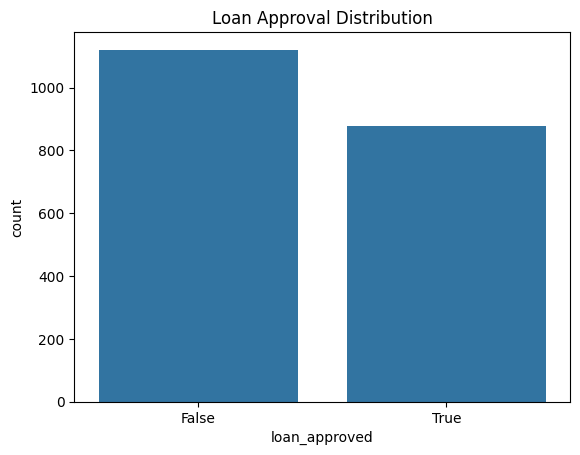

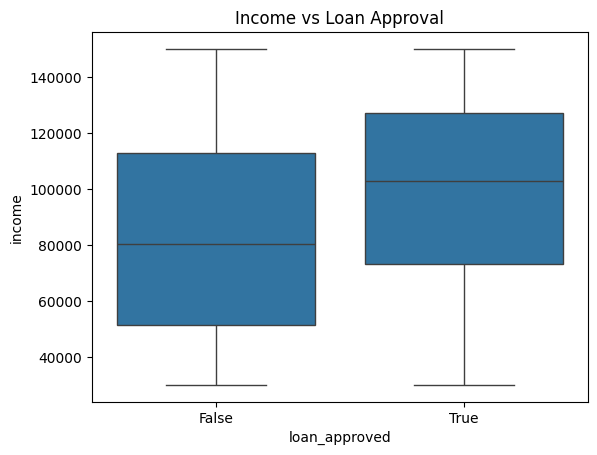

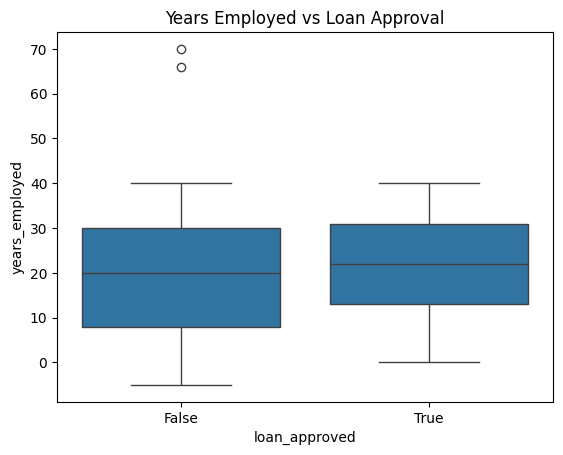

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of target variable
sns.countplot(x='loan_approved', data=df)
plt.title("Loan Approval Distribution")
plt.show()

# Relationship between income and loan approval
sns.boxplot(x='loan_approved', y='income', data=df)
plt.title("Income vs Loan Approval")
plt.show()

# Relationship between years_employed and loan approval
sns.boxplot(x='loan_approved', y='years_employed', data=df)
plt.title("Years Employed vs Loan Approval")
plt.show()

Q4. Outlier Detection and Treatment

In [5]:
# Detect outliers using IQR
Q1 = df['income'].quantile(0.25)
Q3 = df['income'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

# Cap outliers
df['income'] = df['income'].clip(lower, upper)

Q5. Target Variable Conversion

In [6]:
# Convert target variable
df['loan_approved'] = df['loan_approved'].map({True:1, False:0})

# Drop unnecessary columns (like name, city)
df = df.drop(['name','city'], axis=1)


Q6. Feature Selection & Data Splitting

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop('loan_approved', axis=1)
y = df['loan_approved']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


Q7. Feature Scaling

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Q8. Logistic Regression Model Building

In [9]:
from sklearn.linear_model import LogisticRegression

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)


Q9. Model Evaluation - Confusion Matrix





In [10]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Interpretation:
# cm[0,0] = True Negatives
# cm[0,1] = False Positives
# cm[1,0] = False Negatives
# cm[1,1] = True Positives


Confusion Matrix:
 [[333   0]
 [  0 267]]


Q10. Model Evaluation - ROC Curve & AUC

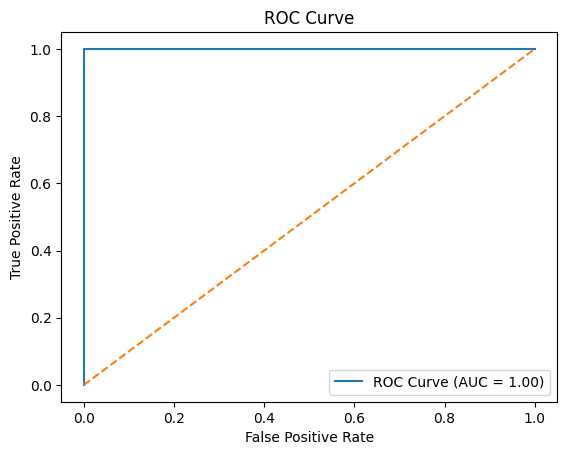

AUC Score: 1.0


In [11]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label="ROC Curve (AUC = %.2f)" % auc_score)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", auc_score)
